In [13]:
import pandas as pd
from pathlib import Path
import numpy as np
import ta
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [14]:
sns.set_style("whitegrid")

plt.rcParams.update({
    'font.size'       : 9,
    'figure.figsize'  : (3.5, 2.8),
    'figure.dpi'      : 300,
    'savefig.dpi'     : 300,
    'text.usetex'     : True,
    'font.family'     : 'serif',
    'font.serif'      : ['Times New Roman'],
    'axes.labelsize'  : 9,
    'axes.titlesize'  : 9,
    'xtick.labelsize' : 8,
    'ytick.labelsize' : 8,
    'legend.fontsize' : 8,
    'lines.linewidth' : 1,
    'axes.linewidth'  : 1,
    'grid.linestyle'  : '--',
    'grid.linewidth'  : 0.5,
    'grid.alpha'      : 0.8,
})

sns.set_context(
    "paper", 
    rc={
        "font.size"      : 9,
        "axes.titlesize" : 9,
        "axes.labelsize" : 9, 
        'xtick.labelsize': 8,
        'ytick.labelsize': 8
    }
)

In [2]:
df = pd.read_parquet("/home/dusoudeth/Documentos/github/monnaie-par-renforcement/data/07_model_output/dqn/analytical_base_table_with_predictions.parquet")
df

,date,open,high,low,close,volume,Actual,SP500,fng_value,DJIA,...,volatility,sma_7,sma_21,rsi,sp500_change,djia_change,day_of_week,month,action,state
0,2023-09-21,27129.839844,27152.939453,26389.300781,26567.632812,13371443708,0.055,4330.00,47.0,34070.42,...,763.638672,26768.028739,26190.413132,54.178097,-1.640089,-1.075640,3,9,0,"[0.9760010621230886, 1.0, 0.20663086768170597,..."
1,2023-09-22,26564.056641,26726.078125,26495.533203,26579.568359,10578746709,0.055,4320.06,43.0,33963.84,...,230.544922,26763.868025,26227.500930,59.370604,-0.229561,-0.312823,4,9,0,"[0.6274727029683788, 0.9295447093203595, 0.499..."
2,2023-09-23,26578.556641,26634.185547,26520.519531,26579.390625,7404700301,0.055,4320.06,47.0,33963.84,...,113.666016,26765.455078,26261.338635,59.532831,0.000000,0.000000,5,9,0,"[0.6292554231715827, 0.7396047422079387, 0.514..."
3,2023-09-24,26579.373047,26716.058594,26221.050781,26256.826172,8192867686,0.055,4320.06,44.0,33963.84,...,495.007812,26725.832031,26275.017671,55.521151,0.000000,0.000000,6,9,0,"[0.7098565281990962, 0.9806382715285087, 0.0, ..."
4,2023-09-25,26253.775391,26421.507812,26011.468750,26298.480469,11997833257,0.055,4337.44,47.0,34006.88,...,410.039062,26660.717634,26298.163597,67.651903,0.402309,0.126723,0,9,0,"[0.37321071567934727, 0.6315591334079378, 0.0,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,2025-03-20,86872.953125,87443.265625,83647.195312,84167.195312,29028988961,0.055,5662.89,37.0,41953.32,...,3796.070312,84101.072545,85091.215030,41.476504,-0.218491,-0.026951,3,3,0,"[0.8497623982037346, 1.0, 0.0, 0.1369837640487..."
547,2025-03-21,84164.539062,84782.273438,83171.070312,84043.242188,19030452299,0.055,5667.56,37.0,41985.35,...,1611.203125,84111.664062,85075.511905,45.631484,0.082467,0.076347,4,3,0,"[0.5216588180160756, 0.8460239114429189, 0.0, ..."
548,2025-03-22,84046.257812,84513.875000,83674.781250,83832.484375,9863214091,0.055,5667.56,37.0,41985.35,...,839.093750,84038.717634,84970.777158,46.195645,0.000000,0.000000,5,3,0,"[0.2866340551555752, 0.647450925570031, 0.0, 0..."
549,2025-03-23,83831.898438,86094.781250,83794.914062,86054.375000,12594615537,0.055,5667.56,37.0,41985.35,...,2299.867188,84535.101562,84580.587798,60.029150,0.000000,0.000000,6,3,0,"[0.016081091639123184, 1.0, 0.0, 0.98243105070..."


In [4]:
df = pd.read_parquet("/home/dusoudeth/Documentos/github/monnaie-par-renforcement/data/07_model_output/dqn/predictions.parquet")
df

,date,state,action,q_values
0,2023-09-21,"[0.9760010621230886, 1.0, 0.20663086768170597,...",0,"[-0.07163222134113312, -0.09695928543806076, -..."
1,2023-09-22,"[0.6274727029683788, 0.9295447093203595, 0.499...",0,"[-0.07273159176111221, -0.09823796153068542, -..."
2,2023-09-23,"[0.6292554231715827, 0.7396047422079387, 0.514...",0,"[-0.0684022605419159, -0.12120763957500458, -0..."
3,2023-09-24,"[0.7098565281990962, 0.9806382715285087, 0.0, ...",0,"[-0.07163222134113312, -0.09695928543806076, -..."
4,2023-09-25,"[0.37321071567934727, 0.6315591334079378, 0.0,...",0,"[-0.07163222134113312, -0.09695928543806076, -..."
...,...,...,...,...
546,2025-03-20,"[0.8497623982037346, 1.0, 0.0, 0.1369837640487...",0,"[-0.07163222134113312, -0.09695928543806076, -..."
547,2025-03-21,"[0.5216588180160756, 0.8460239114429189, 0.0, ...",0,"[-0.07163222134113312, -0.09695928543806076, -..."
548,2025-03-22,"[0.2866340551555752, 0.647450925570031, 0.0, 0...",0,"[-0.07163222134113312, -0.09695928543806076, -..."
549,2025-03-23,"[0.016081091639123184, 1.0, 0.0, 0.98243105070...",0,"[-0.07163222134113312, -0.09695928543806076, -..."


# análise

In [19]:
dqn = pd.read_parquet("/home/dusoudeth/Documentos/github/monnaie-par-renforcement/data/07_model_output/dqn/training_metrics.parquet")
dqn

,episode,total_reward,portfolio_value,portfolio_return_pct,cash,crypto_held,total_invested,avg_buy_price,steps,epsilon,...,action_sell,hold_pct,buy_pct,sell_pct,reward_ma_10,portfolio_ma_10,reward_ma_50,portfolio_ma_50,reward_ma_100,portfolio_ma_100
0,1,-2.364859,542.551825,-94.574482,306.229431,0.009148,244.616987,26215.743938,1296,0.999753,...,431,34.182099,32.561728,33.256173,NaN,NaN,NaN,NaN,NaN,NaN
1,2,-5.521223,308.406609,-96.915934,61.480031,0.009558,256.900832,26349.848570,1296,0.999505,...,425,33.796296,33.410494,32.793210,NaN,NaN,NaN,NaN,NaN,NaN
2,3,-4.142644,322.000455,-96.779995,223.666238,0.003806,104.678244,26960.765191,1296,0.999258,...,430,33.564815,33.256173,33.179012,NaN,NaN,NaN,NaN,NaN,NaN
3,4,-2.942378,734.916612,-92.650834,245.340851,0.018951,516.492909,26719.289612,1296,0.999011,...,433,34.027778,32.561728,33.410494,NaN,NaN,NaN,NaN,NaN,NaN
4,5,-2.464897,657.188888,-93.428111,158.063549,0.019321,514.494373,26106.668957,1296,0.998763,...,435,35.493827,30.941358,33.564815,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,0.341337,37577.312188,275.773122,29837.601077,0.299602,3997.955971,13082.589289,1296,0.010000,...,6,98.533951,1.003086,0.462963,0.355098,27900.680550,-7.272830,24654.755483,-5.606261,23635.551411
4996,4997,0.503656,21944.093253,119.440933,10372.344859,0.447938,4796.629401,10498.267489,1296,0.010000,...,4,98.688272,1.003086,0.308642,0.360470,27440.912527,-7.269295,24585.375300,-5.592471,23741.374328
4997,4998,0.506787,36649.636394,266.496364,1197.398991,1.372344,24747.990061,17679.775062,1296,0.010000,...,7,97.685185,1.774691,0.540123,0.380471,26761.229542,-7.265092,25049.458471,-5.588060,23887.852221
4998,4999,0.510278,30376.563578,203.765636,21303.637537,0.351210,4274.871752,11933.179425,1296,0.010000,...,5,97.993827,1.620370,0.385802,0.383014,26523.192264,-7.251445,25149.996855,-5.589581,24003.041182


In [43]:
dqn_ = pd.read_parquet("/home/dusoudeth/Documentos/github/monnaie-par-renforcement/data/07_model_output/dqn/predictions.parquet")
dqn_

,date,state,action,q_values
0,2023-09-21,"[0.9760010621230886, 1.0, 0.20663086768170597,...",0,"[-0.07163222134113312, -0.09695928543806076, -..."
1,2023-09-22,"[0.6274727029683788, 0.9295447093203595, 0.499...",0,"[-0.07273159176111221, -0.09823796153068542, -..."
2,2023-09-23,"[0.6292554231715827, 0.7396047422079387, 0.514...",0,"[-0.0684022605419159, -0.12120763957500458, -0..."
3,2023-09-24,"[0.7098565281990962, 0.9806382715285087, 0.0, ...",0,"[-0.07163222134113312, -0.09695928543806076, -..."
4,2023-09-25,"[0.37321071567934727, 0.6315591334079378, 0.0,...",0,"[-0.07163222134113312, -0.09695928543806076, -..."
...,...,...,...,...
546,2025-03-20,"[0.8497623982037346, 1.0, 0.0, 0.1369837640487...",0,"[-0.07163222134113312, -0.09695928543806076, -..."
547,2025-03-21,"[0.5216588180160756, 0.8460239114429189, 0.0, ...",0,"[-0.07163222134113312, -0.09695928543806076, -..."
548,2025-03-22,"[0.2866340551555752, 0.647450925570031, 0.0, 0...",0,"[-0.07163222134113312, -0.09695928543806076, -..."
549,2025-03-23,"[0.016081091639123184, 1.0, 0.0, 0.98243105070...",0,"[-0.07163222134113312, -0.09695928543806076, -..."


In [20]:
lstm = pd.read_parquet("/home/dusoudeth/Documentos/github/monnaie-par-renforcement/data/07_model_output/dqn_lstm/training_metrics.parquet")
lstm

,episode,total_reward,portfolio_value,portfolio_return_pct,cash,crypto_held,total_invested,avg_buy_price,steps,epsilon,...,action_sell,hold_pct,buy_pct,sell_pct,reward_ma_10,portfolio_ma_10,reward_ma_50,portfolio_ma_50,reward_ma_100,portfolio_ma_100
0,1,-2.137337,1142.633856,-88.573661,1015.678371,0.004914,137.763363,27482.910215,1282,0.999753,...,430,34.165367,32.293292,33.541342,NaN,NaN,NaN,NaN,NaN,NaN
1,2,-2.218918,614.487137,-93.855129,256.605843,0.013853,368.616426,26086.519339,1282,0.999505,...,418,34.165367,33.229329,32.605304,NaN,NaN,NaN,NaN,NaN,NaN
2,3,-2.725288,544.030430,-94.559696,167.104703,0.014591,390.372390,26230.330557,1282,0.999258,...,407,34.087363,34.165367,31.747270,NaN,NaN,NaN,NaN,NaN,NaN
3,4,-2.984268,443.425636,-95.565744,114.432832,0.012735,335.705781,25843.591792,1282,0.999011,...,462,30.109204,33.853354,36.037441,NaN,NaN,NaN,NaN,NaN,NaN
4,5,-3.155476,472.071793,-95.279282,204.444680,0.010360,282.152868,26701.447836,1282,0.998763,...,446,33.151326,32.059282,34.789392,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,-0.372610,7002.260920,-29.977391,917.908191,0.235523,6470.951230,26936.067662,1282,0.010000,...,67,84.165367,10.608424,5.226209,-0.062664,26224.754806,0.066775,22741.376406,0.062837,21855.140018
4996,4997,-0.174304,27673.645331,176.736453,675.522093,1.045088,28586.881874,26817.214317,1282,0.010000,...,18,84.789392,13.806552,1.404056,-0.079100,27066.232554,0.060460,23016.446088,0.061080,21783.787852
4997,4998,-0.413926,10712.601127,7.126011,3233.484482,0.289514,8036.998001,27215.981738,1282,0.010000,...,69,79.173167,15.444618,5.382215,-0.125218,24709.684483,0.051788,23026.992062,0.058014,21656.877587
4998,4999,-0.771624,30466.663461,204.666635,9557.019065,0.809405,22587.182749,27358.725994,1282,0.010000,...,26,76.911076,21.060842,2.028081,-0.210552,24213.889084,0.031536,23246.522362,0.049298,21769.324016


In [45]:
lstm_ = pd.read_parquet("/home/dusoudeth/Documentos/github/monnaie-par-renforcement/data/07_model_output/dqn_lstm/predictions.parquet")
lstm_

,date,state,action,q_values
0,2023-10-05,"[0.9882667554095935, 1.0088527545693127, 0.986...",0,"[0.07488004863262177, 0.07232452183961868, 0.0..."
1,2023-10-06,"[0.9971860700189692, 1.0087116148233686, 0.986...",1,"[0.04492238163948059, 0.04569867253303528, 0.0..."
2,2023-10-07,"[1.00142718937643, 1.0070192075842317, 0.99644...",0,"[0.05457484349608421, 0.05165105313062668, 0.0..."
3,2023-10-08,"[1.0012715759385886, 1.0031585872706674, 0.996...",0,"[0.05461464077234268, 0.05168375000357628, 0.0..."
4,2023-10-09,"[0.9917289084574081, 1.0246858855533636, 0.987...",0,"[0.05461464077234268, 0.05168375000357628, 0.0..."
...,...,...,...,...
532,2025-03-20,"[0.9925934370342536, 1.0271126339345706, 0.981...",0,"[0.015688326209783554, 0.003221750259399414, 0..."
533,2025-03-21,"[1.003942222709888, 1.007861667104177, 0.92741...",0,"[0.032423555850982666, 0.015582196414470673, 0..."
534,2025-03-22,"[0.9807275370649609, 1.0057001012978015, 0.973...",0,"[0.045303963124752045, 0.017051488161087036, 0..."
535,2025-03-23,"[0.9128675078783292, 1.0084360726136705, 0.902...",0,"[0.015742868185043335, -0.009906213730573654, ..."


In [65]:
data_dir = Path("../data/02_intermediate")
btc = pd.read_parquet(data_dir / "historical_data_btc.parquet")
btc['date'] = pd.to_datetime(btc['formatted_date'])
# filter > 2023-10-05
btc = btc[btc['date'] > '2023-10-05']

display(btc)

initial_cash = 10000.0
buy_fee = 0.02  # 2% fee
dca_percentage = 0.25  # 25% of remaining cash

cash = initial_cash
btc_held = 0.0
total_invested = 0.0
portfolio_values = []
transactions = []

btc['weekday'] = btc['date'].dt.dayofweek  # Monday = 0
mondays = btc[btc['weekday'] == 0].copy()

for idx, row in mondays.iterrows():
   date = row['date']
   price = row['close']
   # Calculate purchase amount (25% of remaining cash)
   purchase_amount = cash * dca_percentage
   if purchase_amount > 0:
       # Calculate BTC amount after fees
       btc_amount = purchase_amount / (price * (1 + buy_fee))
       cost_with_fees = btc_amount * price * (1 + buy_fee)
       # Update positions
       cash -= cost_with_fees
       btc_held += btc_amount
       total_invested += cost_with_fees
       # Record transaction
       transactions.append({
           'date': date,
           'action': 'BUY',
           'price': price,
           'btc_amount': btc_amount,
           'cost': cost_with_fees,
           'cash_remaining': cash,
           'btc_held': btc_held,
           'portfolio_value': cash + (btc_held * price)
       })

# Calculate final portfolio value
final_price = btc.iloc[-1]['close']
final_portfolio_value = cash + (btc_held * final_price)
total_return = (final_portfolio_value - initial_cash) / initial_cash * 100
avg_buy_price = total_invested / btc_held if btc_held > 0 else 0

print("\n" + "="*80)
print("DOLLAR COST AVERAGE SIMULATION RESULTS")
print("="*80)
print(f"Initial Investment: ${initial_cash:,.2f}")
print(f"Total Invested: ${total_invested:,.2f}")
print(f"Final Cash: ${cash:,.2f}")
print(f"BTC Held: {btc_held:.6f}")
print(f"Average Buy Price: ${avg_buy_price:,.2f}")
print(f"Final BTC Price: ${final_price:,.2f}")
print(f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
print(f"Total Return: {total_return:.2f}%")
print(f"Number of Purchases: {len(transactions)}")

# Calculate buy-and-hold comparison
initial_price = btc.iloc[0]['close']
bah_btc = initial_cash / (initial_price * (1 + buy_fee))
bah_final_value = bah_btc * final_price
bah_return = (bah_final_value - initial_cash) / initial_cash * 100

print(f"\nBuy-and-Hold Comparison:")
print(f"B&H BTC Amount: {bah_btc:.6f}")
print(f"B&H Final Value: ${bah_final_value:,.2f}")
print(f"B&H Return: {bah_return:.2f}%")
print(f"DCA vs B&H Difference: {total_return - bah_return:.2f} percentage points")

# Create detailed transactions DataFrame
transactions_df = pd.DataFrame(transactions)
if not transactions_df.empty:
   print(f"\nFirst 5 transactions:")
   print(transactions_df.head()[['date', 'price', 'btc_amount', 'cost', 'portfolio_value']].round(4))
   
   print(f"\nLast 5 transactions:")
   print(transactions_df.tail()[['date', 'price', 'btc_amount', 'cost', 'portfolio_value']].round(4))

# Calculate some additional metrics
if len(transactions) > 1:
   price_range = f"${mondays['close'].min():,.2f} - ${mondays['close'].max():,.2f}"
   avg_purchase_amount = transactions_df['cost'].mean()
   print(f"\nAdditional Metrics:")
   print(f"Price Range During DCA: {price_range}")
   print(f"Average Purchase Amount: ${avg_purchase_amount:,.2f}")
   print(f"Total Fees Paid: ${total_invested - transactions_df['btc_amount'].sum() * avg_buy_price:,.2f}")

,date,high,low,open,close,volume,adjclose,formatted_date
1374,2023-10-06,28252.537109,27215.552734,27412.123047,27946.597656,13492391599,27946.597656,2023-10-06
1375,2023-10-07,28028.091797,27870.423828,27946.781250,27968.839844,6553044316,27968.839844,2023-10-07
1376,2023-10-08,28102.169922,27740.662109,27971.677734,27935.089844,7916875290,27935.089844,2023-10-08
1377,2023-10-09,27989.470703,27302.562500,27934.472656,27583.677734,12007668568,27583.677734,2023-10-09
1378,2023-10-10,27715.847656,27301.654297,27589.201172,27391.019531,9973350678,27391.019531,2023-10-10
...,...,...,...,...,...,...,...,...
1906,2025-03-21,84782.273438,83171.070312,84164.539062,84043.242188,19030452299,84043.242188,2025-03-21
1907,2025-03-22,84513.875000,83674.781250,84046.257812,83832.484375,9863214091,83832.484375,2025-03-22
1908,2025-03-23,86094.781250,83794.914062,83831.898438,86054.375000,12594615537,86054.375000,2025-03-23
1909,2025-03-24,88758.726562,85541.195312,86070.929688,87498.914062,34582604933,87498.914062,2025-03-24



DOLLAR COST AVERAGE SIMULATION RESULTS
Initial Investment: $10,000.00
Total Invested: $10,000.00
Final Cash: $0.00
BTC Held: 0.306170
Average Buy Price: $32,661.59
Final BTC Price: $87,867.30
Final Portfolio Value: $26,902.33
Total Return: 169.02%
Number of Purchases: 77

Buy-and-Hold Comparison:
B&H BTC Amount: 0.350809
B&H Final Value: $30,824.65
B&H Return: 208.25%
DCA vs B&H Difference: -39.22 percentage points

First 5 transactions:
        date       price  btc_amount       cost  portfolio_value
0 2023-10-09  27583.6777      0.0889  2500.0000        9950.9804
1 2023-10-16  28519.4668      0.0645  1875.0000        9997.3663
2 2023-10-23  33086.2344      0.0417  1406.2500       10669.9314
3 2023-10-30  34502.3633      0.0300  1054.6875       10925.3693
4 2023-11-06  35037.3711      0.0221   791.0156       11030.2092

Last 5 transactions:
         date       price  btc_amount  cost  portfolio_value
72 2025-02-24  91418.1719         0.0   0.0       27989.5017
73 2025-03-03  86065.67

/tmp/ipykernel_8806/2946432028.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  axs.plot(i, btc.query(f"date == '{i}'")["close"], marker="v", markersize=5, color="green", label="Buy (LSTM)" if i == lstm_.query("action == 1")["date"].iloc[0] else "")
/tmp/ipykernel_8806/2946432028.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  axs.plot(i, btc.query(f"date == '{i}'")["close"], marker="v", markersize=5, color="green", label="Buy (LSTM)" if i == lstm_.query("action == 1")["date"].iloc[0] else "")
/tmp/ipykernel_8806/2946432028.py:6: FutureWarning: The behavior of 'isin' wit

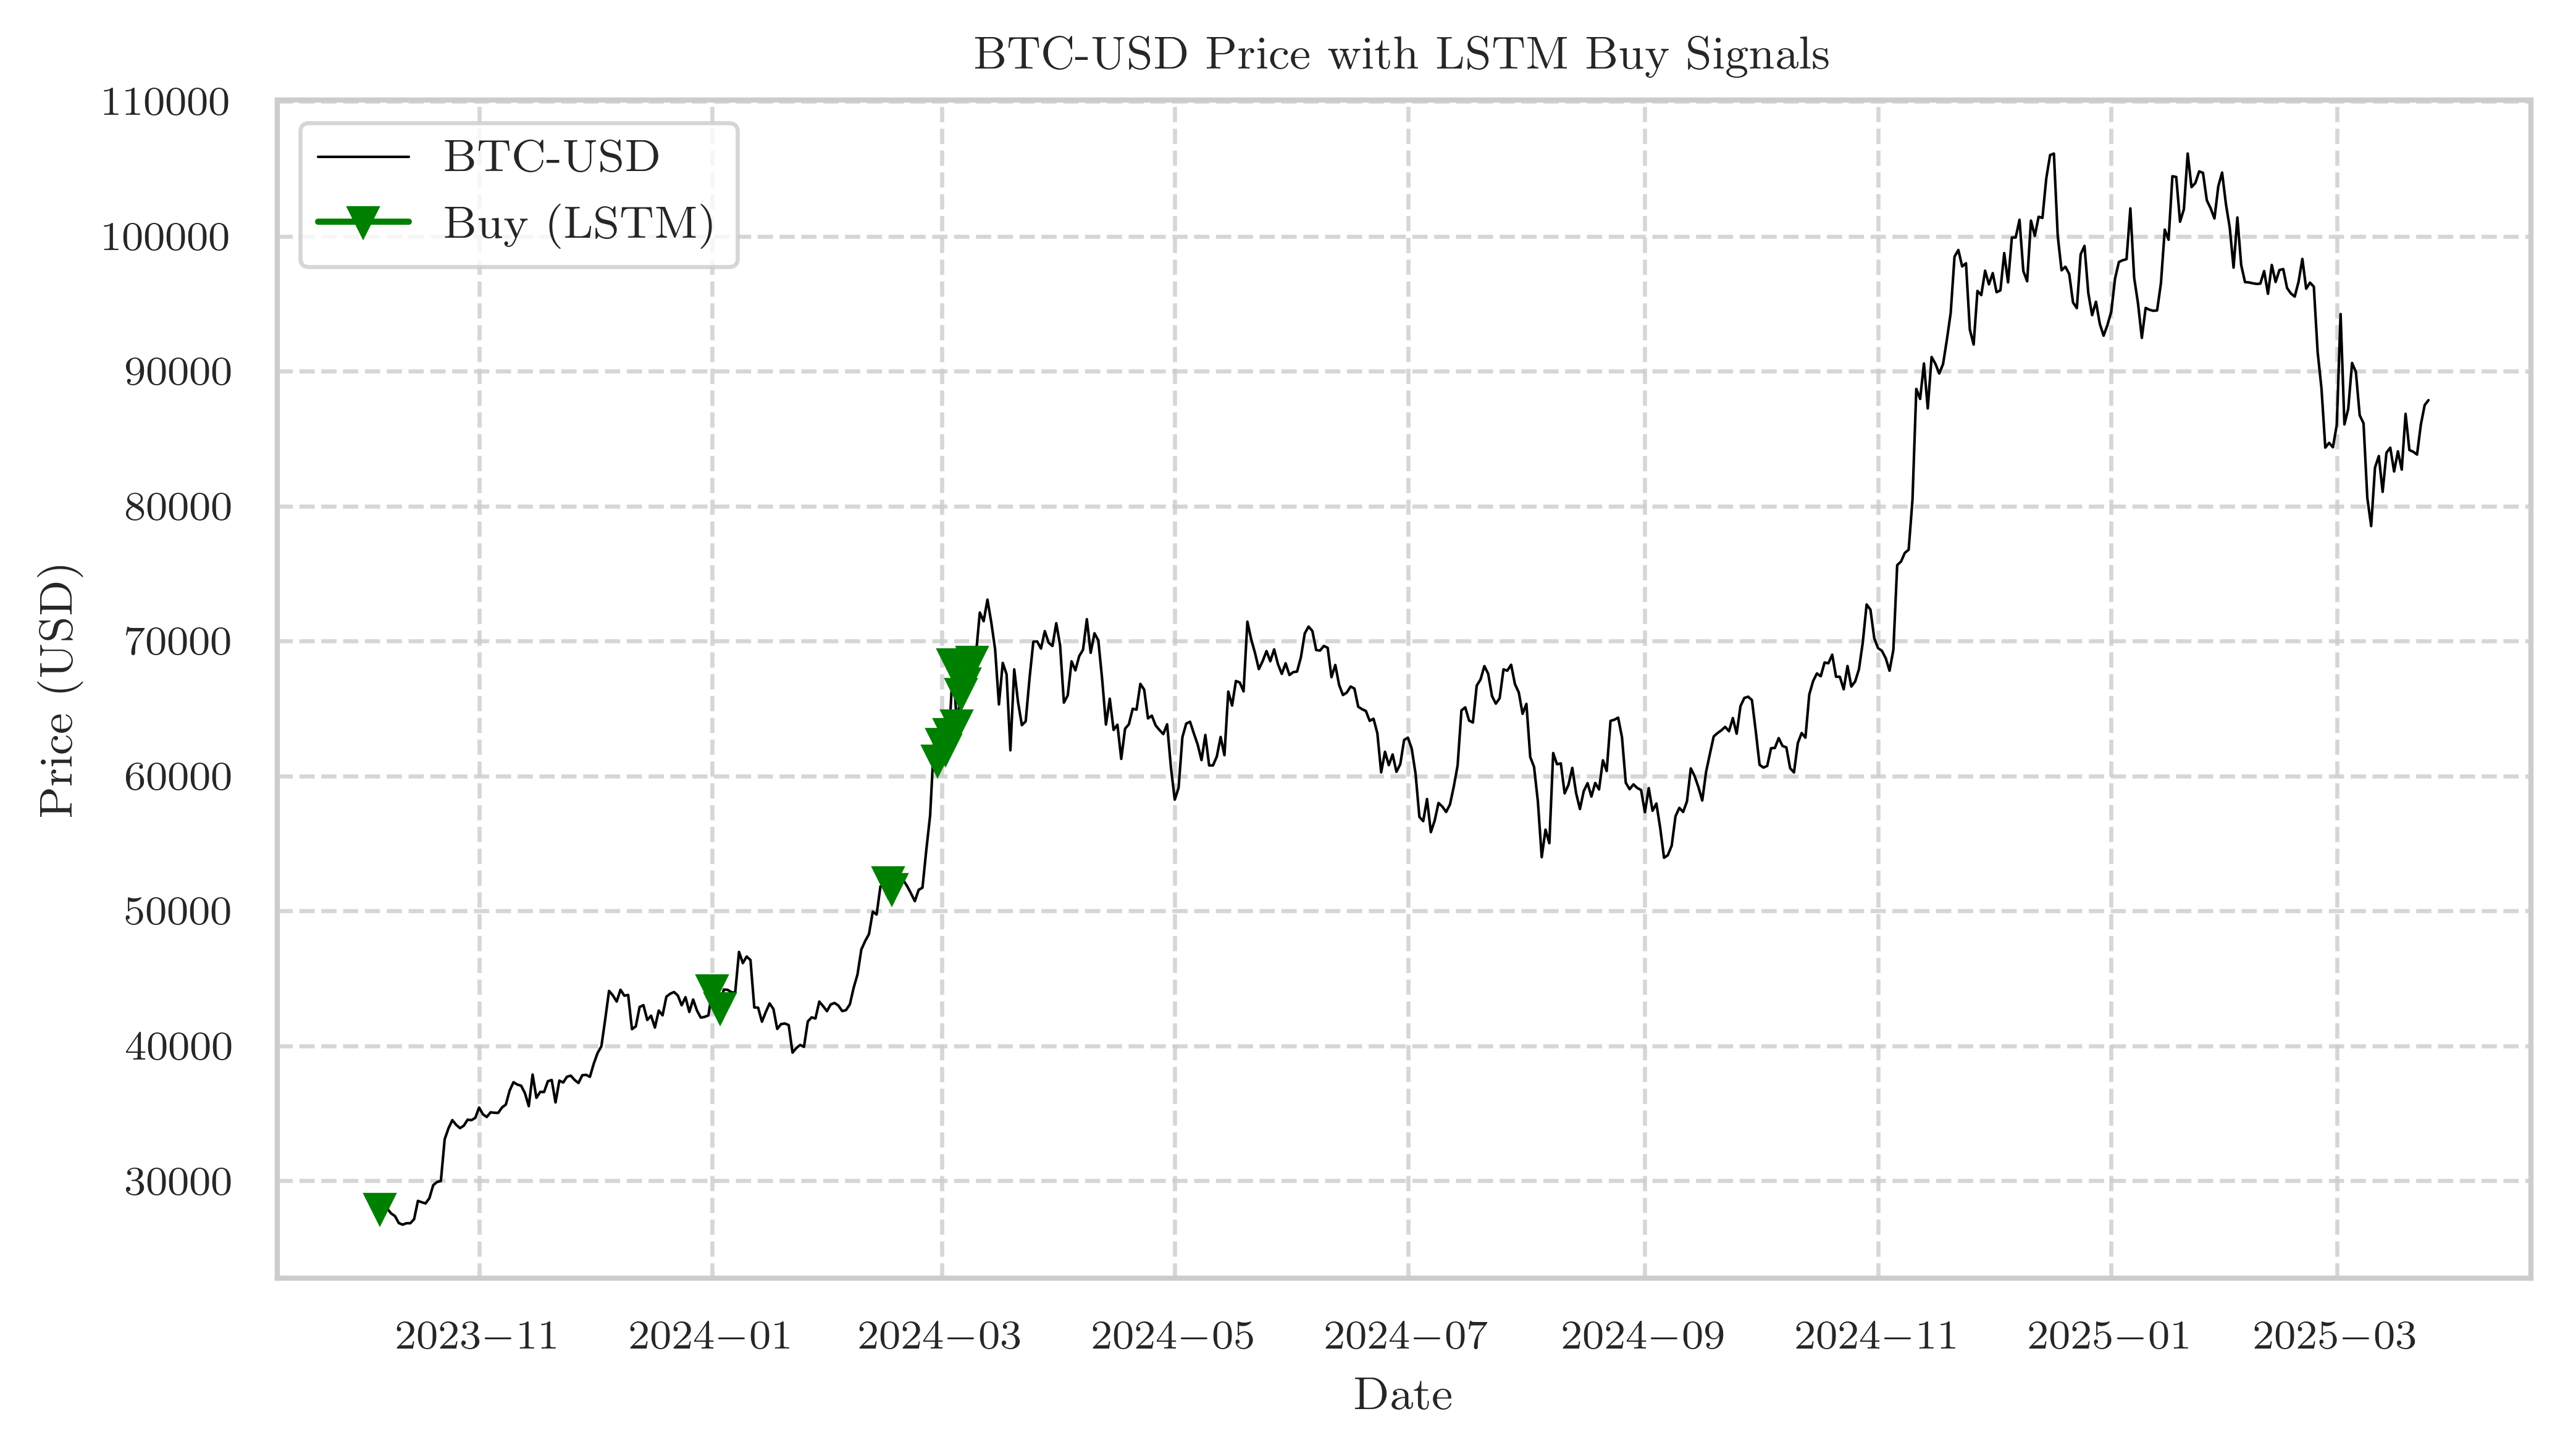

In [62]:
_, axs = plt.subplots(figsize=(7, 4),)

axs.plot(btc['date'], btc["close"], label="BTC-USD", color="black", linewidth=0.5)
for i in lstm_.query("action == 1")["date"]:
    # print green triangle down to indicate buy
    axs.plot(i, btc.query(f"date == '{i}'")["close"], marker="v", markersize=5, color="green", label="Buy (LSTM)" if i == lstm_.query("action == 1")["date"].iloc[0] else "")
axs.legend()
#
axs.set_xlabel("Date")
axs.set_ylabel("Price (USD)")
axs.set_title("BTC-USD Price with LSTM Buy Signals")
plt.tight_layout()
plt.savefig("../data/plots/btc_lstm_buy_signals.png", dpi=300, bbox_inches='tight')

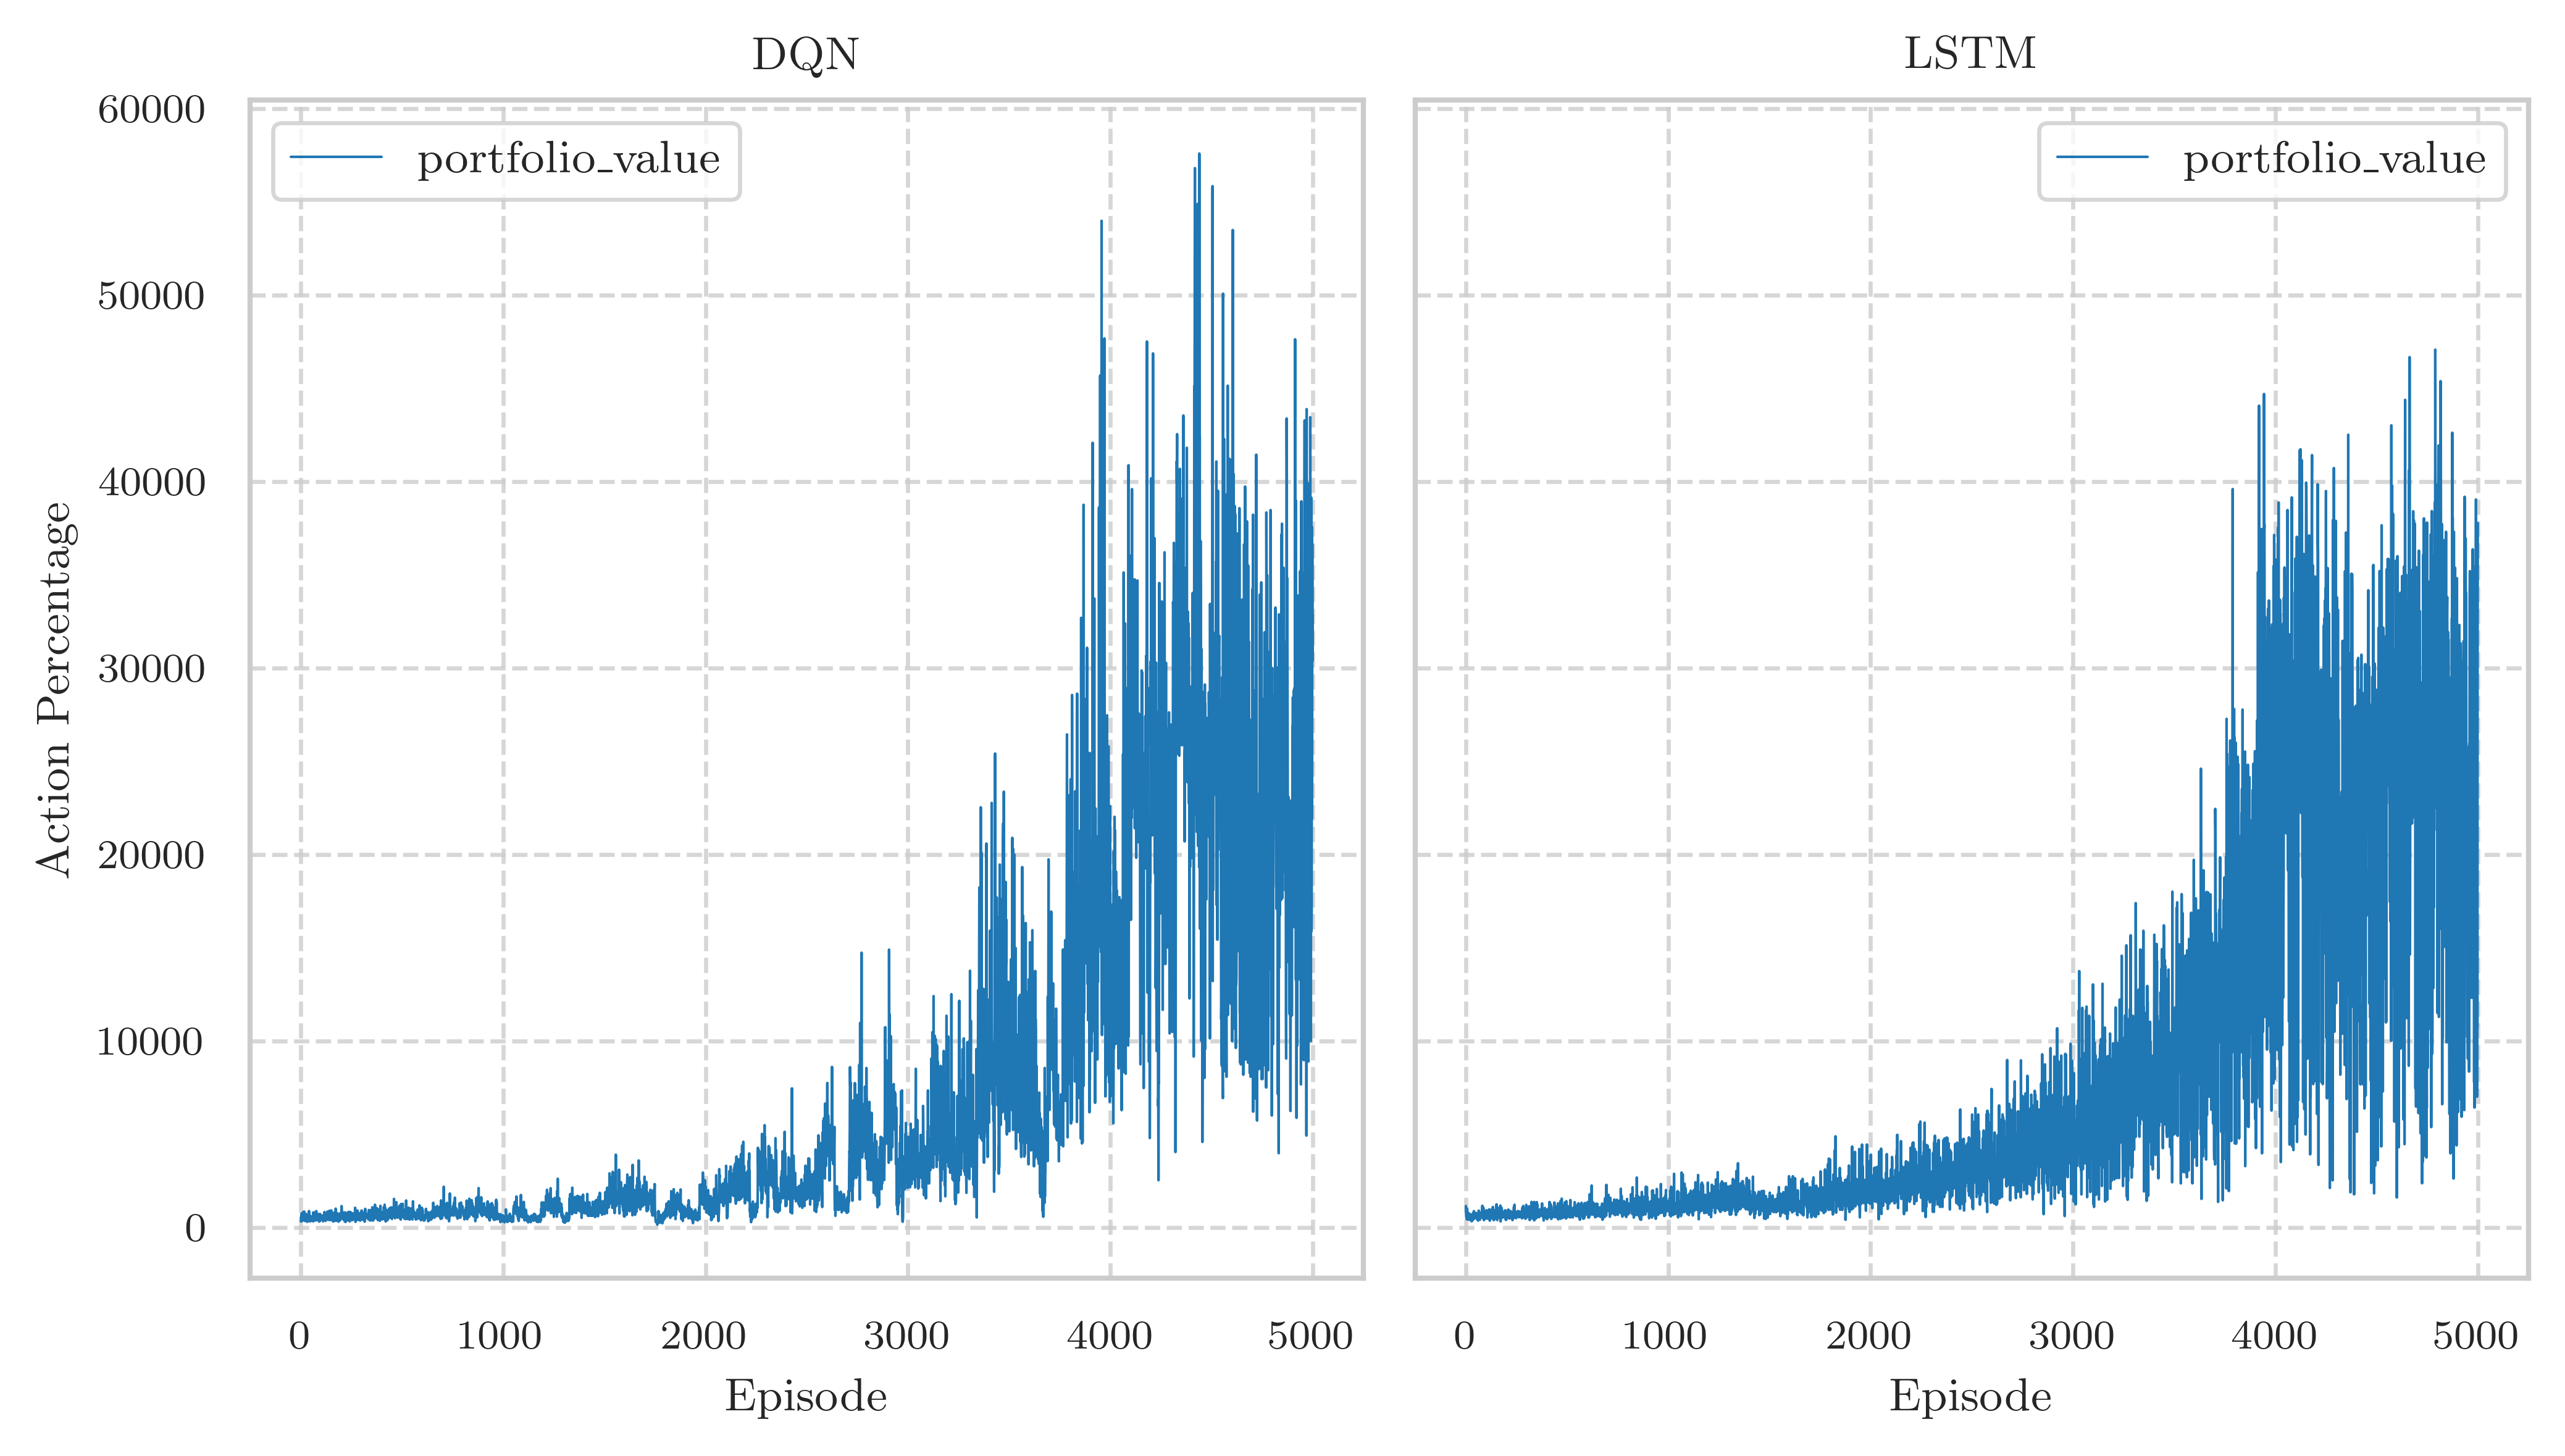

In [42]:
_, axs = plt.subplots(ncols=2, figsize=(7, 4), sharey=True)

dqn.plot(
    x="episode",
    y=['portfolio_value',],
    ax=axs[0],
    linewidth=0.5,
)
axs[0].set_title("DQN")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Action Percentage")

lstm.plot(
    x="episode",
    y=['portfolio_value',],
    ax=axs[1],
    linewidth=0.5,
)
axs[1].set_title("LSTM")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Action Percentage")

plt.tight_layout()
plt.savefig("../data/plots/dqn_lstm_portfolio_value.png", dpi=300, bbox_inches='tight')

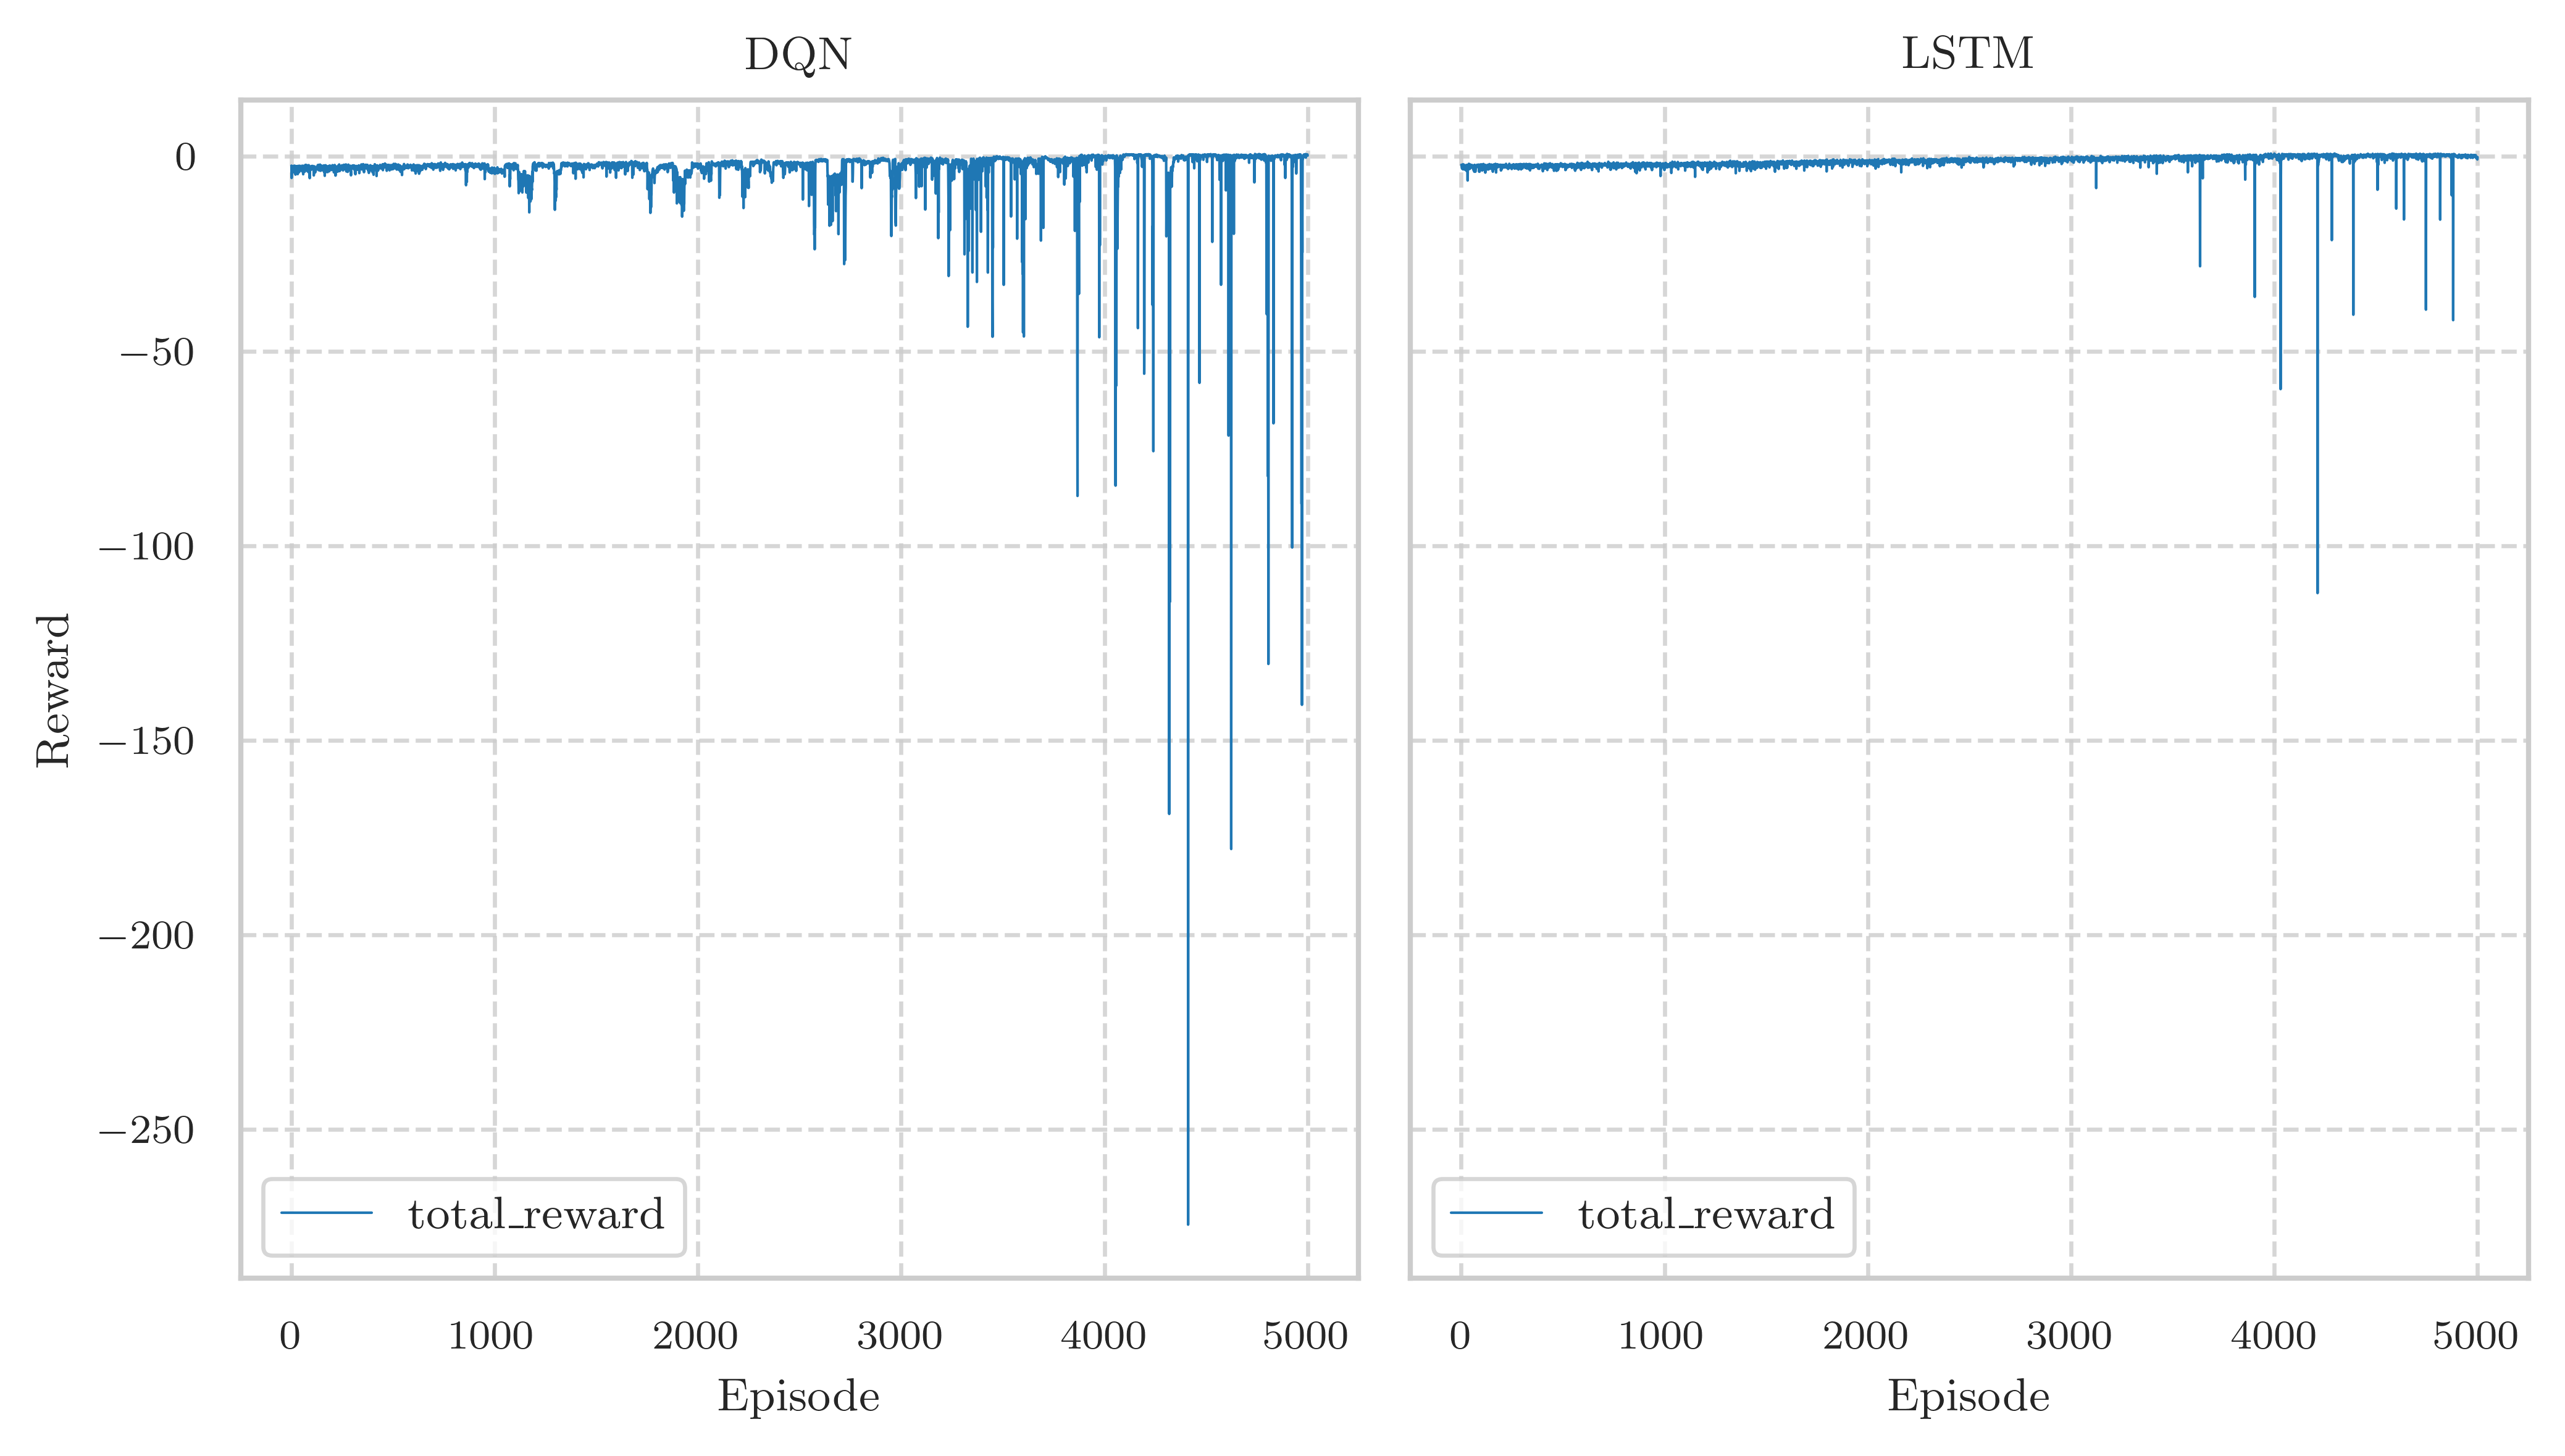

In [44]:
_, axs = plt.subplots(ncols=2, figsize=(7, 4), sharey=True)

dqn.plot(
    x="episode",
    y=['total_reward',],
    ax=axs[0],
    linewidth=0.5,
)
axs[0].set_title("DQN")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Reward")

lstm.plot(
    x="episode",
    y=['total_reward',],
    ax=axs[1],
    linewidth=0.5,
)
axs[1].set_title("LSTM")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Reward")

plt.tight_layout()
plt.savefig("../data/plots/dqn_lstm_rewards.png", dpi=300, bbox_inches='tight')

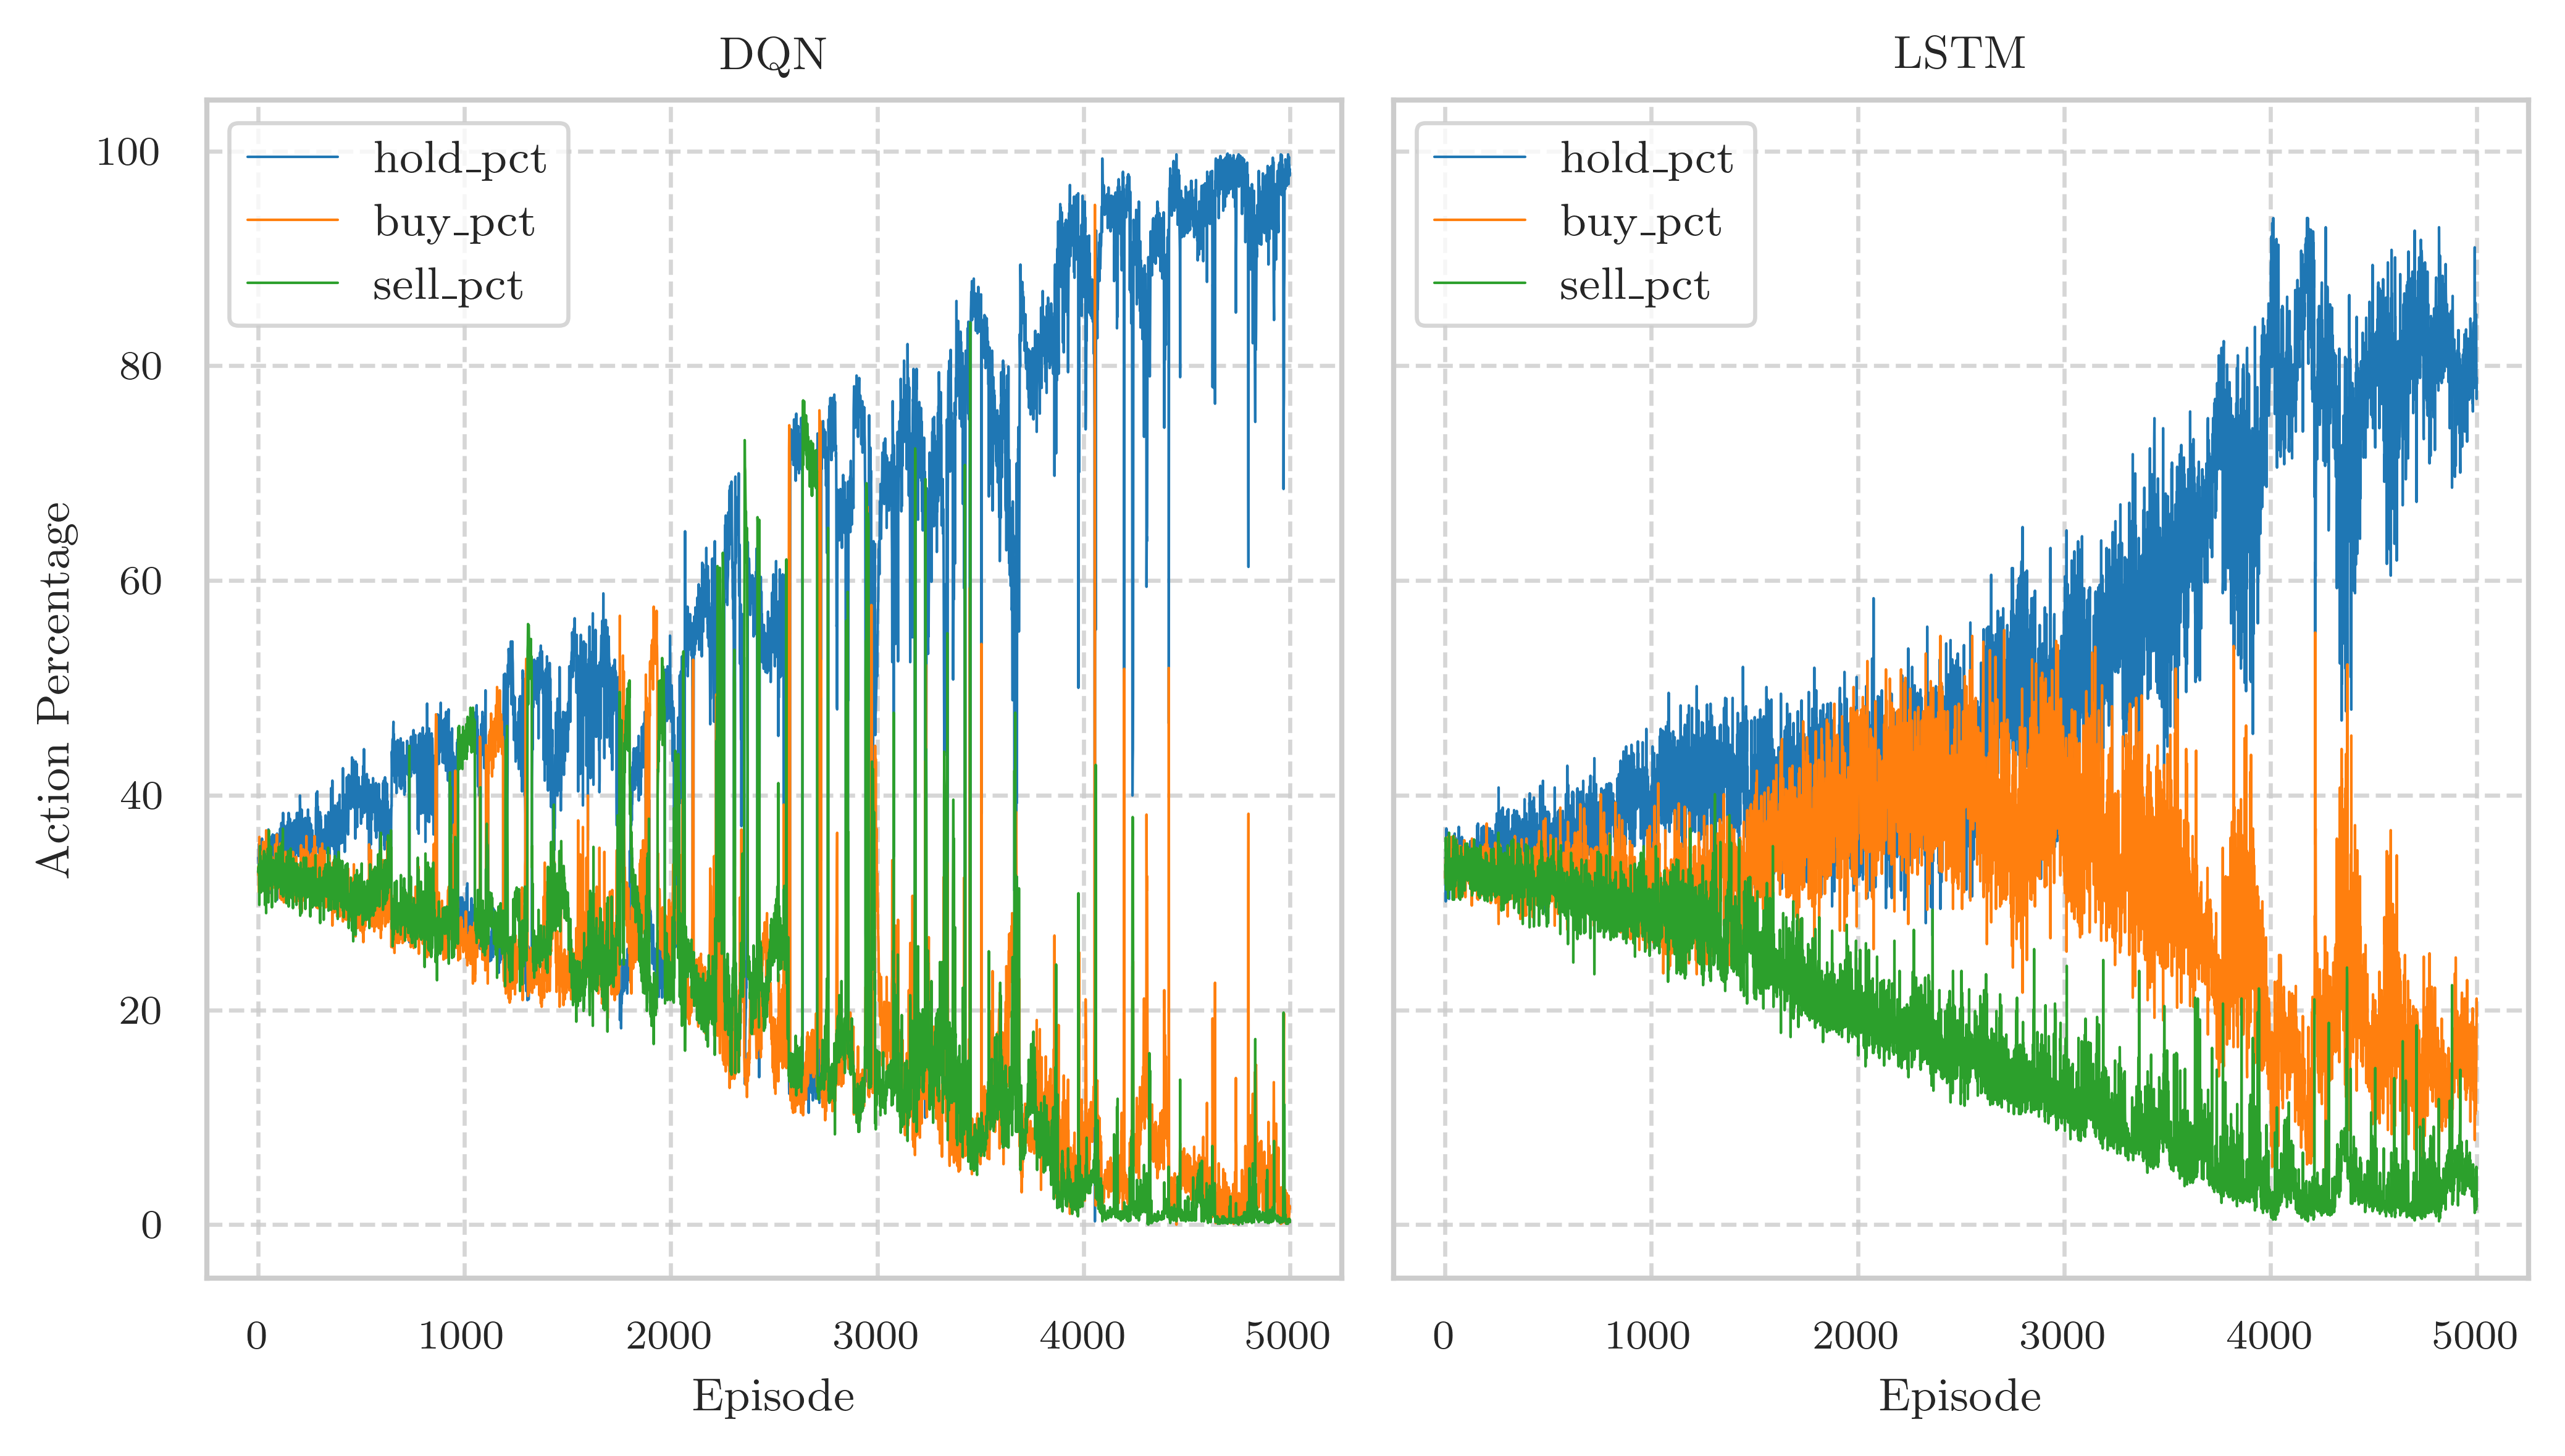

In [40]:
_, axs = plt.subplots(ncols=2, figsize=(7, 4), sharey=True)

dqn.plot(
    x="episode",
    y=['hold_pct', 	'buy_pct',	'sell_pct'],
    ax=axs[0],
    linewidth=0.5,
)
axs[0].set_title("DQN")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Action Percentage")

lstm.plot(
    x="episode",
    y=['hold_pct', 	'buy_pct',	'sell_pct'],
    ax=axs[1],
    linewidth=0.5,
)
axs[1].set_title("LSTM")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Action Percentage")

plt.tight_layout()
plt.savefig("../data/plots/dqn_lstm_action_counts.png", dpi=300, bbox_inches='tight')

In [ ]:
_, axs = plt.subplots(ncols=2, figsize=(7, 4))

dqn.plot(
    x="episode",
    y=['action_hold', 	'action_buy',	'action_sell'],
    ax=axs[0],
    linewidth=0.5,
)
axs[0].set_title("DQN")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Action Count")

lstm.plot(
    x="episode",
    y=['action_hold', 	'action_buy',	'action_sell'],
    ax=axs[1],
    linewidth=0.5,
)
axs[1].set_title("LSTM")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Action Count")

plt.tight_layout()
plt.savefig("../data/plots/dqn_lstm_action_counts.png", dpi=300, bbox_inches='tight')

In [7]:
# open /home/dusoudeth/Documentos/github/monnaie-par-renforcement/data/logs/dqn/training_20250608_213850.log
with open("/home/dusoudeth/Documentos/github/monnaie-par-renforcement/data/logs/dqn/training_20250608_213850.log", "r") as f:
    lines = f.readlines()
len(lines)

40770

.